# Pilot 1 — basic EDA

Pilot 1 was a small "does everything work?" run. Five basic questions for this notebook:

1. **Dropout** — where do people fall off?
2. **Highlighting** — how often are people highlighting, and what are they highlighting?
3. **Accuracy** — are people getting the comprehension questions right? does it differ by condition?
4. **Bug reports** — anything submitted?
5. **Sanity checks** — anyone obviously rushing or stuck?

Loads the Pilot1 tab from the logging Google Sheet, exported as
`data/speechspectrum-study-logging - Pilot1.csv`. Re-export that tab over the
same file and re-run all cells to refresh.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 100)

# Pilot 1 lives on its own tab in the logging sheet — export that tab and
# load it directly. No timestamp slicing needed.
CSV = Path('../data/speechspectrum-study-logging - Pilot1.csv')

raw = pd.read_csv(CSV)
# Sheets sometimes appends trailing empty columns as "Unnamed: N" — drop them
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed:')]
raw['timestamp'] = pd.to_datetime(raw['timestamp'], errors='coerce', utc=True)
for c in ['event_type','prolific_id','assigned_condition','question_id','question_text','response','extra']:
    raw[c] = raw[c].fillna('') if c in raw.columns else ''
raw['style'] = raw['assigned_condition'].str.split(' / ').str[0]

# Strip TEST PIDs by default
EXCLUDE_TEST = True
df = raw.copy()
if EXCLUDE_TEST:
    df = df[~df['prolific_id'].str.upper().str.startswith('TEST')].copy()

n_pid = df['prolific_id'][df['prolific_id'] != ''].nunique()
print(f'Pilot 1 — {len(df)} rows, {n_pid} unique participants')
df['event_type'].value_counts()

Pilot 1 — 1966 rows, 23 unique participants


event_type
question_timing         636
survey_response         615
demographic             154
page_timing              98
style_switch             93
post_survey              87
question_order           83
transcript_timing        77
irb_consent              30
condition_assignment     24
study_start              23
content_ack              21
study_complete           17
practice_response         3
page_view                 2
study_exit                1
style_duration            1
2026-05-20T00:00:00Z      1
Name: count, dtype: int64

## 1. Dropout funnel

,stage,n,unit
0,saw consent page,30,events
1,agreed to consent,30,events
2,declined consent,0,events
3,entered Prolific ID,22,participants
4,finished demographics,22,participants
5,agreed to content ack *,19,participants (event added mid-Pilot 1; undercounts)
6,declined content ack *,1,participants (same caveat)
7,started study task,21,participants
8,reached the end,17,participants (union of study_complete | post_survey)


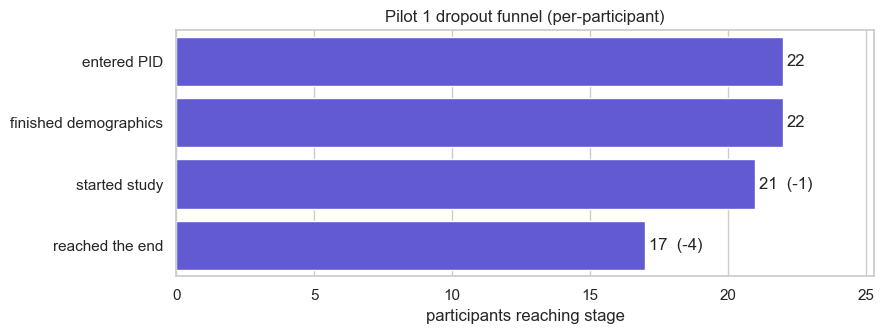

In [2]:
"""
Three quirks to handle in the funnel:

  1) Consent events (page_timing/consent, irb_consent) are logged BEFORE the
     Prolific ID is entered, so they don't carry a PID. We count those as
     event rows, not unique participants.

  2) sendBeacon is fire-and-forget — occasionally one drops. In Pilot 1 one
     participant has post_survey events but no study_complete, so we count
     "reached the end" as the UNION of study_complete and post_survey.

  3) Some logging events (page_timing, content_ack) were added partway
     through the codebase, so early Pilot 1 participants are missing them.
     For "finished demographics" we use the presence of any `demographic`
     event row per PID (logged from day 1).
"""

# Pre-PID stages: count event rows (no PID available)
n_consent_seen     = ((df['event_type']=='page_timing') & (df['question_id']=='consent')).sum()
n_consent_agreed   = ((df['event_type']=='irb_consent') & (df['response']=='agreed')).sum()
n_consent_declined = ((df['event_type']=='irb_consent') & (df['response']=='declined')).sum()

# PID-bearing stages: count unique participants
def pids_with(evt, qid=None, resp=None):
    sub = df[df['event_type']==evt]
    if qid is not None:  sub = sub[sub['question_id']==qid]
    if resp is not None: sub = sub[sub['response']==resp]
    return set(sub['prolific_id']) - {''}

pid_entered      = pids_with('condition_assignment')
finished_demo    = set(df[df['event_type']=='demographic']['prolific_id']) - {''}
content_ack_yes  = pids_with('content_ack', resp='agreed')
content_ack_no   = pids_with('content_ack', resp='declined')
started_study    = pids_with('study_start')
completed        = pids_with('study_complete')
post_survey_done = pids_with('post_survey')
reached_end      = completed | post_survey_done   # union — covers lost beacons

rows = [
    {'stage': 'saw consent page',           'n': n_consent_seen,        'unit': 'events'},
    {'stage': '   agreed to consent',       'n': n_consent_agreed,      'unit': 'events'},
    {'stage': '   declined consent',        'n': n_consent_declined,    'unit': 'events'},
    {'stage': 'entered Prolific ID',        'n': len(pid_entered),      'unit': 'participants'},
    {'stage': 'finished demographics',      'n': len(finished_demo),    'unit': 'participants'},
    {'stage': 'agreed to content ack *',    'n': len(content_ack_yes),  'unit': 'participants (event added mid-Pilot 1; undercounts)'},
    {'stage': '   declined content ack *',  'n': len(content_ack_no),   'unit': 'participants (same caveat)'},
    {'stage': 'started study task',         'n': len(started_study),    'unit': 'participants'},
    {'stage': 'reached the end',            'n': len(reached_end),      'unit': 'participants (union of study_complete | post_survey)'},
]
funnel = pd.DataFrame(rows)
display(funnel)

# Bar chart of the reliably-logged participant-level stages
pid_funnel = pd.DataFrame([
    ('entered PID',           len(pid_entered)),
    ('finished demographics', len(finished_demo)),
    ('started study',         len(started_study)),
    ('reached the end',       len(reached_end)),
], columns=['stage','n'])
pid_funnel['drop'] = pid_funnel['n'].diff().fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.barplot(pid_funnel, x='n', y='stage', ax=ax, color='#4F46E5')
for i, (v, d) in enumerate(zip(pid_funnel['n'], pid_funnel['drop'])):
    label = f'{v}'
    if i > 0 and d != 0:
        label += f'  ({d:+d})'
    ax.text(v + 0.15, i, label, va='center')
ax.set_xlim(0, pid_funnel['n'].max() * 1.15)
ax.set_title('Pilot 1 dropout funnel (per-participant)')
ax.set_xlabel('participants reaching stage'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [3]:
# Any explicit exit-button presses?
exits = df[df['event_type']=='study_exit'][['timestamp','prolific_id','extra']]
print(f'Explicit study_exit events: {len(exits)}')
display(exits)

Explicit study_exit events: 1


,timestamp,prolific_id,extra
1291,2026-05-08 11:27:22.263000+00:00,69cc110782388aa27b96206e,from_task_html


### Keep only participants who reached the end

Everything below the funnel restricts to participants who reached either `study_complete` or `post_survey` (the same definition of "reached the end" used in the funnel above). This means timing, highlighting, accuracy, and demographics all describe the **finishers**, not the people who bounced.

In [4]:
# Restrict df to participants who reached the end.
# `reached_end` was computed in the funnel cell above as
# (PIDs in study_complete) ∪ (PIDs in post_survey).
df_all = df.copy()  # keep an unfiltered copy in case you want to compare later
df = df[df['prolific_id'].isin(reached_end)].copy()

print(f'Before: {df_all["prolific_id"].nunique()} unique participants')
print(f'After (reached the end): {df["prolific_id"].nunique()} unique participants')
print(f'Dropped:  {df_all["prolific_id"].nunique() - df["prolific_id"].nunique()}')

Before: 24 unique participants
After (reached the end): 17 unique participants
Dropped:  7


## 2. Completion times & timing

Run before excluding anyone so we can see who's rushing or stuck.
Use the table to spot PIDs to add to Section 3's exclusion list.

Internal (study_complete) — n=17 completers
  median = 51.4 min   mean = 49.5 min
  IQR    = 37.6 – 62.6 min
  range  = 3.6 – 111.2 min

Prolific (Time taken)  — n=18 participants who started
  median = 61.6 min   mean = 3040.1 min
  IQR    = 49.1 – 70.9 min
  range  = 16.0 – 17983.8 min


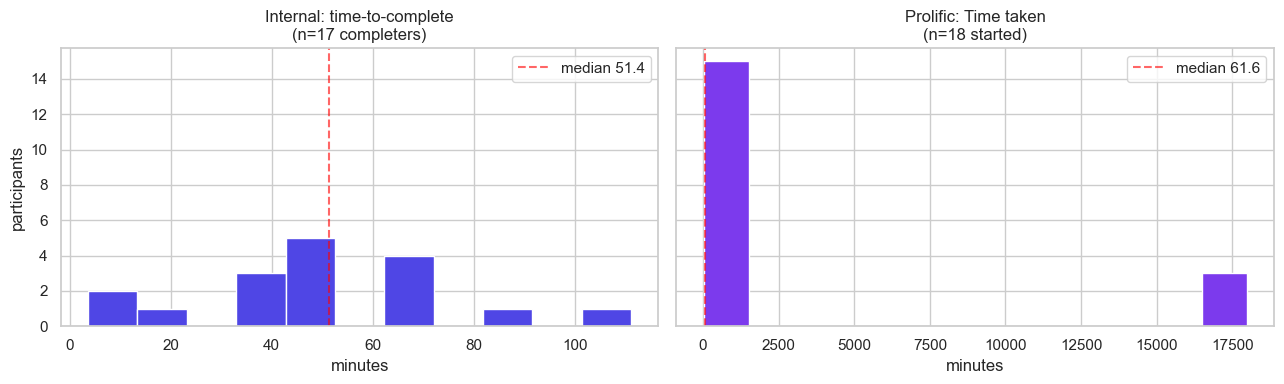

In [5]:
# Completion time — two views:
#   (A) Internal `study_complete` event: time from study_start to the end. Only completers.
#   (B) Prolific `Time taken` (from the Prolific export): total time the participant
#       spent in the study link, including any who returned or timed out. More comprehensive.

# --- (A) Internal ---
comp = df[df['event_type']=='study_complete'].copy()
def total_sec(e):
    try: return json.loads(e).get('total_time_seconds')
    except: return None
comp['minutes'] = pd.to_numeric(comp['extra'].apply(total_sec), errors='coerce') / 60
int_min = comp['minutes'].dropna()
print(f'Internal (study_complete) — n={len(int_min)} completers')
if len(int_min):
    print(f'  median = {int_min.median():.1f} min   mean = {int_min.mean():.1f} min')
    print(f'  IQR    = {int_min.quantile(.25):.1f} – {int_min.quantile(.75):.1f} min')
    print(f'  range  = {int_min.min():.1f} – {int_min.max():.1f} min')

# --- (B) Prolific ---
_pp = sorted(Path('../data').glob('pilot1-prolific_demographic_export_*.csv'))
if _pp:
    _prolific = pd.read_csv(_pp[0])
    prol_min = pd.to_numeric(_prolific['Time taken'], errors='coerce').dropna() / 60
    print(f'\nProlific (Time taken)  — n={len(prol_min)} participants who started')
    if len(prol_min):
        print(f'  median = {prol_min.median():.1f} min   mean = {prol_min.mean():.1f} min')
        print(f'  IQR    = {prol_min.quantile(.25):.1f} – {prol_min.quantile(.75):.1f} min')
        print(f'  range  = {prol_min.min():.1f} – {prol_min.max():.1f} min')
else:
    prol_min = pd.Series(dtype=float)
    print('\n(No Prolific export found yet — drop into data/.)')

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
bins_a = max(8, min(20, int(len(int_min)/1.5))) if len(int_min) else 5
axes[0].hist(int_min, bins=bins_a, color='#4F46E5', edgecolor='white')
if len(int_min):
    axes[0].axvline(int_min.median(), color='red', linestyle='--', alpha=0.6, label=f'median {int_min.median():.1f}')
    axes[0].legend()
axes[0].set_title(f'Internal: time-to-complete\n(n={len(int_min)} completers)')
axes[0].set_xlabel('minutes'); axes[0].set_ylabel('participants')

bins_b = max(8, min(20, int(len(prol_min)/1.5))) if len(prol_min) else 5
axes[1].hist(prol_min, bins=bins_b, color='#7C3AED', edgecolor='white')
if len(prol_min):
    axes[1].axvline(prol_min.median(), color='red', linestyle='--', alpha=0.6, label=f'median {prol_min.median():.1f}')
    axes[1].legend()
axes[1].set_title(f'Prolific: Time taken\n(n={len(prol_min)} started)')
axes[1].set_xlabel('minutes')

plt.tight_layout(); plt.show()

In [6]:
# Per-participant median question time (no accuracy yet — that comes in Section 6).
qt = df[df['event_type']=='question_timing'].copy()
def get_sec(e):
    try: return json.loads(e).get('duration_seconds')
    except: return None
qt['seconds'] = pd.to_numeric(qt['extra'].apply(get_sec), errors='coerce')

pid_style = (df[df['event_type']=='condition_assignment']
             .sort_values('timestamp').drop_duplicates('prolific_id', keep='first')
             [['prolific_id','style']])
pp_timing = (qt.groupby('prolific_id')
               .agg(median_q_sec=('seconds','median'),
                    n_questions=('seconds','count'))
               .reset_index()
               .merge(pid_style, on='prolific_id', how='left')
               .sort_values('median_q_sec'))
display(pp_timing)

,prolific_id,median_q_sec,n_questions,style
8,69c41799dfcdff198b56a122,2.60,32,enhanced
16,69fce82bde339dace5d6a513,5.70,63,enhanced
6,672ceecd4b982fd2123fa32f,23.55,32,bullet-points
3,629e1738fcc7d0b6acfe5280,45.50,31,enhanced
15,69f6e0090d0fdfa6256181d6,58.60,31,bullet-points
7,67d9ef30fe8af2858e8dbbd3,59.05,32,demo
5,661124ea6eb49e5f25077328,60.50,31,verbatim
0,5addd5e8a7f2df000154665b,72.30,31,demo
9,69d59bb26cbbb9ca14a5eb04,78.55,30,enhanced
4,642ead184d7533ccfd57d888,81.10,33,verbatim


## 3. Exclude participants

Add Prolific IDs to `EXCLUDE_PIDS` to drop them from every analysis below.
Common reasons: rushed (Section 2 table), returned the study, comprehension-check failed.

Re-run all cells below this one after editing the list.

In [7]:
EXCLUDE_PIDS = {
    # 'paste a prolific id here',
    # one per line — examples to consider:
    #   median question time < 5s (Section 2 table)
    #   comprehension free-text empty/random
    #   Prolific Status is RETURNED or TIMED-OUT
    "69c41799dfcdff198b56a122", # too fast
    "69fce82bde339dace5d6a513", # too fast
    "672ceecd4b982fd2123fa32f" # accuracy too low
}

before = df['prolific_id'].nunique()
if EXCLUDE_PIDS:
    df = df[~df['prolific_id'].isin(EXCLUDE_PIDS)].copy()
after = df['prolific_id'].nunique()
print(f'Excluded {len(EXCLUDE_PIDS)} PIDs — participants: {before} → {after}')

Excluded 3 PIDs — participants: 17 → 14


## 4. Bug reports

In [8]:
bugs = df[df['event_type']=='bug_report'][['timestamp','prolific_id','style','response']]
print(f'{len(bugs)} bug reports submitted')
display(bugs)

0 bug reports submitted


,timestamp,prolific_id,style,response


## 5. Highlighting behavior

In [9]:
sr = df[df['event_type']=='survey_response'].copy()

def parse_extra(e):
    try: return json.loads(e) if e else {}
    except Exception: return {}
sr['parsed'] = sr['extra'].apply(parse_extra)
sr['highlights'] = sr['parsed'].apply(lambda d: d.get('highlights', []))
sr['n_highlights'] = sr['highlights'].apply(len)
sr['chars_highlighted'] = sr['highlights'].apply(lambda hs: sum(len((h or {}).get('text','')) for h in hs))
sr['transcript'] = sr['question_id'].str.split('_').str[0]
sr['no_info_chosen'] = sr['response'].str.startswith('This interaction is not shown')

print(f'survey_response rows: {len(sr)}')
print(f'  rows with at least 1 highlight: {(sr["n_highlights"]>0).sum()} ({(sr["n_highlights"]>0).mean():.0%})')
print(f'  rows where E ("not in transcript") was chosen: {sr["no_info_chosen"].sum()} ({sr["no_info_chosen"].mean():.0%})')
print(f'  mean highlights/question (incl. zeros): {sr["n_highlights"].mean():.2f}')
print(f'  mean highlights/question (highlighted only): {sr.loc[sr["n_highlights"]>0, "n_highlights"].mean():.2f}')
print(f'  mean chars highlighted/question: {sr["chars_highlighted"].mean():.0f}')

survey_response rows: 440
  rows with at least 1 highlight: 412 (94%)
  rows where E ("not in transcript") was chosen: 48 (11%)
  mean highlights/question (incl. zeros): 1.33
  mean highlights/question (highlighted only): 1.42
  mean chars highlighted/question: 206


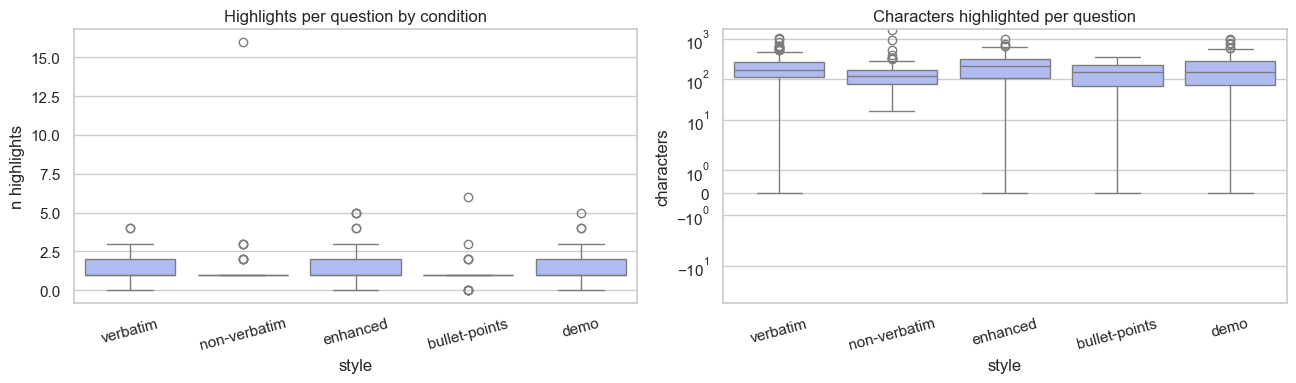

In [10]:
# Highlight intensity by condition
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
order_styles = [s for s in ['verbatim','non-verbatim','enhanced','bullet-points','demo'] if s in sr['style'].unique()]

sns.boxplot(sr[sr['style'].isin(order_styles)], x='style', y='n_highlights',
            order=order_styles, ax=axes[0], color='#A5B4FC')
axes[0].set_title('Highlights per question by condition')
axes[0].set_ylabel('n highlights')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(sr[sr['style'].isin(order_styles)], x='style', y='chars_highlighted',
            order=order_styles, ax=axes[1], color='#A5B4FC')
axes[1].set_title('Characters highlighted per question')
axes[1].set_ylabel('characters'); axes[1].set_yscale('symlog')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

In [11]:
# Sample highlights (what did people actually pick?)
sample = (sr[sr['n_highlights']>0]
          .sample(min(12, (sr['n_highlights']>0).sum()), random_state=0)
          [['style','transcript','question_id','response','highlights']])
for _, r in sample.iterrows():
    print(f'--- [{r["style"]}] {r["transcript"]} {r["question_id"]} → answered: {str(r["response"])[:60]}')
    for h in (r['highlights'] or [])[:3]:
        snippet = (h.get('text') or '').replace('\n', ' ').strip()
        if len(snippet) > 200: snippet = snippet[:200] + '…'
        if 'style' in (h or {}):
            print(f'     [from {h["style"]}] {snippet}')
        else:
            print(f'     {snippet}')
    if len(r['highlights'] or []) > 3:
        print(f'     ... ({len(r["highlights"]) - 3} more)')

--- [verbatim] TranscrC TranscrC_q4 → answered: This comment actually makes the letter more believable — som
     [from Verbatim] Please overlook the extreme, stilted, and awkward language of this letter. This has been something I have been wrestling with over the last week
--- [enhanced] TranscrC TranscrC_q8 → answered: 
     [from Enhanced] her recommendation was not based on family reconciliation or idealized notions of forgiveness, but on her assessment of Lorenze’s current ability to function
--- [enhanced] TranscrC TranscrC_q5 → answered: Cizauskas is testing whether Lorenze's stated principle is g
     [from Enhanced] recognizing that accepting an apology should not be her responsibility and that any such interaction must occur only on her terms.
--- [verbatim] TranscrB TranscrB_q4 → answered: The repetition is a routine conversational acknowledgment wi
     [from Verbatim] They're serious incidents. I know they happened a long time ago, but it's very concerning, you know. BATES

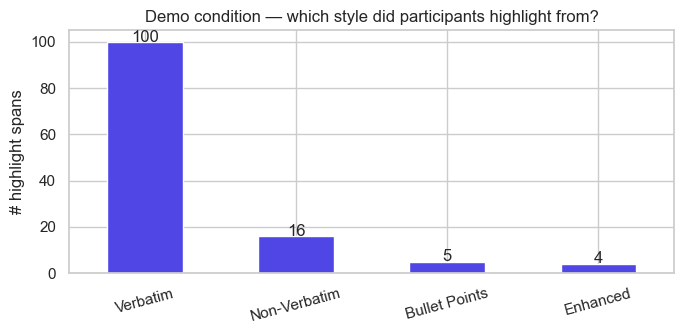

In [12]:
# In the demo condition, each highlight records which transcript STYLE it came from.
demo_hl = sr[sr['style']=='demo'].copy()
if len(demo_hl):
    spans = []
    for _, r in demo_hl.iterrows():
        for h in (r['highlights'] or []):
            if h.get('style'):
                spans.append(h['style'])
    if spans:
        s = pd.Series(spans).value_counts()
        fig, ax = plt.subplots(figsize=(7,3.5))
        s.plot.bar(ax=ax, color='#4F46E5')
        for i, v in enumerate(s.values): ax.text(i, v+0.2, str(v), ha='center')
        ax.set_title('Demo condition — which style did participants highlight from?')
        ax.set_ylabel('# highlight spans')
        ax.tick_params(axis='x', rotation=15)
        plt.tight_layout(); plt.show()
    else:
        print('Demo participants did not record any spans with a style attribute.')
else:
    print('No demo-condition participants in Pilot 1.')

## 6. Comprehension accuracy by condition

In [13]:
import re
qjs = Path('../docs/questions.js').read_text(encoding='utf-8')
m = re.search(r'QUESTIONS_BY_TRANSCRIPT\s*=\s*(\{.*?\});', qjs, re.S)
QBT = json.loads(m.group(1))

E_OPTION = 'This interaction is not shown in the transcript / Not enough information to answer this question'
LETTERS = ['A','B','C','D','E']

# Build (qid -> options list incl. E) and (qid -> correct_letter)
qid_options, qid_correct_letter = {}, {}
for tkey, qs in QBT.items():
    for q in qs:
        qid_options[q['id']] = list(q.get('options') or []) + [E_OPTION]
        if q.get('correct_letter'):
            qid_correct_letter[q['id']] = q['correct_letter']
print(f'{len(qid_correct_letter)} keyed questions across {len(QBT)} transcripts')

# --- Step 1: derive the LETTER the participant clicked ---------------------
# For each saved response, figure out which of the 5 options (A–E) it
# corresponds to. Handles two cases:
#   (a) exact match against an option's text
#   (b) the Pilot-1 truncation bug: saved value was cut at first inner "
#       so the response is a UNIQUE prefix of one option.
def derive_letter(response, options):
    resp = str(response).strip()
    if not resp:
        return None
    for i, opt in enumerate(options):
        if resp == opt.strip():
            return LETTERS[i]
    hits = [i for i, opt in enumerate(options) if opt.startswith(resp)]
    return LETTERS[hits[0]] if len(hits) == 1 else None

# --- Step 2: simple letter equality for scoring ----------------------------
def score_letter(chosen, correct):
    if chosen is None or correct is None:
        return None
    return int(chosen == correct)

sr['chosen_letter']  = sr.apply(lambda r: derive_letter(r['response'], qid_options.get(r['question_id'], [])), axis=1)
sr['correct_letter'] = sr['question_id'].map(qid_correct_letter)
sr['correct']        = sr.apply(lambda r: score_letter(r['chosen_letter'], r['correct_letter']), axis=1)

scored = sr.dropna(subset=['correct']).copy()

# Drop Pilot-1 unusable questions (every option started with " → saved
# values were all empty strings → derive_letter returns None anyway, but
# we drop them explicitly so they don't show up at the bottom of accuracy).
UNUSABLE_QIDS = {'TranscrB_q6', 'TranscrC_q8'}
n_before = len(scored)
scored = scored[~scored['question_id'].isin(UNUSABLE_QIDS)].copy()
print(f'{n_before} scored rows → dropped {n_before - len(scored)} from {sorted(UNUSABLE_QIDS)} → {len(scored)} for accuracy analysis')

print('\nletter-derivation outcomes (in the usable scored set):')
print(scored['chosen_letter'].value_counts(dropna=False).reindex(LETTERS + [None], fill_value=0).to_string())

32 keyed questions across 4 transcripts
440 scored rows → dropped 28 from ['TranscrB_q6', 'TranscrC_q8'] → 412 for accuracy analysis

letter-derivation outcomes (in the usable scored set):
chosen_letter
A       79
B      101
C      141
D       48
E       43
NaN      0


In [14]:
# --- Proof that the letter-derivation is correct -----------------------------
# Three checks:
#   1. Every chosen_letter is one of A/B/C/D/E (or None for unrecoverable rows).
#   2. The text of the option at chosen_letter is either equal to the saved
#      response OR has it as a unique prefix (truncation-bug case).
#   3. correct_letter from the questions.js key matches what we'd expect by
#      looking at the ✅-marked option in questions_raw/*.txt.

# Check 1 ----------------------------------------------------------
bad = sr[sr['chosen_letter'].notna() & ~sr['chosen_letter'].isin(LETTERS)]
assert len(bad) == 0, f'unexpected non-letter values: {bad["chosen_letter"].unique()}'
print('✅ check 1: every chosen_letter is in', LETTERS)

# Check 2 — re-derive from the saved data and confirm consistency -
def is_consistent(row):
    qid = row['question_id']
    if qid not in qid_options: return None
    letter = row['chosen_letter']
    if letter is None: return None
    idx = LETTERS.index(letter)
    opts = qid_options[qid]
    if idx >= len(opts): return False
    opt = opts[idx]
    resp = str(row['response']).strip()
    return (resp == opt.strip()) or (opt.startswith(resp) and bool(resp))

sr_check = sr[sr['chosen_letter'].notna()].copy()
sr_check['ok'] = sr_check.apply(is_consistent, axis=1)
n_ok, n_total = sr_check['ok'].sum(), len(sr_check)
print(f'✅ check 2: {n_ok}/{n_total} responses are consistent with the option text at their derived letter '
      f'({"PASS" if n_ok == n_total else "FAIL"})')

# Check 3 — correct_letter from QBT matches the index of the ✅ option in raw
import re as _re
qjs_raw = Path('../questions_raw/TranscrA_Davis.txt').read_text()
# pull (letter, has_check) for each option in the first question block
sample_block = qjs_raw.split('\n\nL')[0]
print('\n   sanity peek at raw Davis Q1:')
for ln in sample_block.splitlines():
    s = ln.strip()
    if _re.match(r'^(✅\s*)?[A-D]\)', s):
        print('     ', s[:100])
print(f'   key from questions.js for TranscrA_q1 = {qid_correct_letter.get("TranscrA_q1")}')
print('   → should match the ✅-marked option above')

# Check 4 — a small accuracy sanity table: per-letter chosen vs. correctness ─
sample = scored.groupby(['question_id','chosen_letter']).size().unstack(fill_value=0)
print('\nchoice counts per question (rows) × chosen letter (cols), first 6 questions:')
display(sample.head(6))

✅ check 1: every chosen_letter is in ['A', 'B', 'C', 'D', 'E']
✅ check 2: 417/417 responses are consistent with the option text at their derived letter (PASS)

   sanity peek at raw Davis Q1:
      A) Assault, risk of injury to a minor, and failure to register
      ✅B) Assault, risk of injury to a minor, and probation violation
      C) Strangulation, risk of injury to a minor, and probation violation
      D) Assault, child endangerment, and probation violation
      A) Three years
      B) Four years
      ✅C) Six years
      D) Eight years
      A) She is confidently asserting that her drinking is fully under control
      ✅B) She is being careful about how she says it, aware the answer could make her look bad
      C) She is simply stating that she doesn’t drink often, with no particular weight behind it
      D) She is putting on a show of sobriety for the panel by minimizing how often she drinks
      A) She is giving a prepared and organized account of her reasons for seeking t

chosen_letter,A,B,C,D,E
question_id,,,,,
TranscrA_q1,0,12,1,0,1
TranscrA_q2,1,0,11,0,2
TranscrA_q3,3,6,3,2,0
TranscrA_q4,5,1,5,2,1
TranscrA_q5,1,3,3,4,3
TranscrA_q6,6,5,0,1,2


,style,accuracy,n_items
0,bullet-points,0.233333,30
1,demo,0.511111,90
2,enhanced,0.411111,90
3,non-verbatim,0.536585,82
4,verbatim,0.641667,120


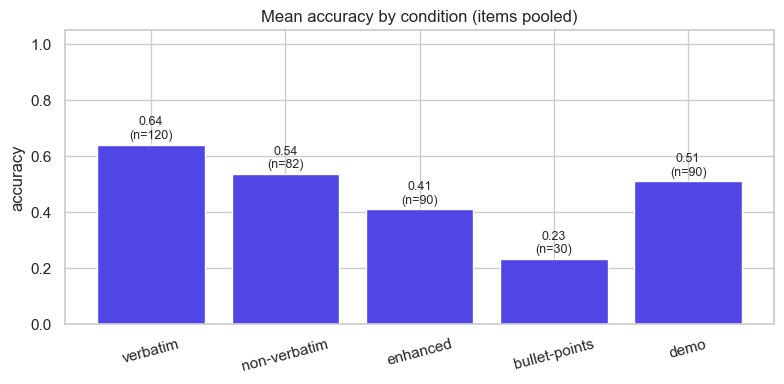

In [15]:
# Overall accuracy by condition
by_cond = (scored.groupby('style')['correct']
           .agg(['mean','count']).rename(columns={'mean':'accuracy','count':'n_items'})
           .reset_index())
display(by_cond)

fig, ax = plt.subplots(figsize=(8,4))
by_cond_sorted = by_cond.set_index('style').reindex([s for s in order_styles if s in by_cond['style'].values]).reset_index()
ax.bar(by_cond_sorted['style'], by_cond_sorted['accuracy'], color='#4F46E5')
for i, (a, n) in enumerate(zip(by_cond_sorted['accuracy'], by_cond_sorted['n_items'])):
    ax.text(i, a + 0.02, f'{a:.2f}\n(n={int(n)})', ha='center', fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel('accuracy')
ax.set_title('Mean accuracy by condition (items pooled)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

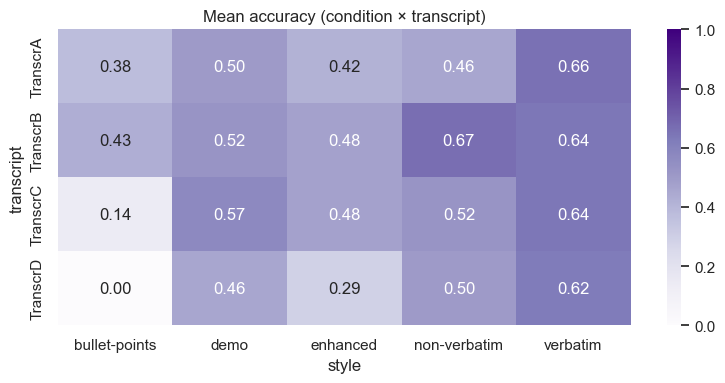

In [16]:
# Accuracy by condition × transcript
by_ct = (scored.groupby(['style','transcript'])['correct'].mean().reset_index())
pivot = by_ct.pivot(index='transcript', columns='style', values='correct').reindex(
    index=['TranscrA','TranscrB','TranscrC','TranscrD']
)
fig, ax = plt.subplots(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Purples', vmin=0, vmax=1, ax=ax)
ax.set_title('Mean accuracy (condition × transcript)')
plt.tight_layout(); plt.show()

In [17]:
# Per-question hit rate — surfaces any question that's broken (e.g., near 0 or near 1 across everyone)
per_q = (scored.groupby(['transcript','question_id'])['correct']
         .agg(['mean','count']).rename(columns={'mean':'accuracy','count':'n'})
         .reset_index().sort_values(['transcript','accuracy']))
display(per_q)

,transcript,question_id,accuracy,n
4,TranscrA,TranscrA_q5,0.285714,14
3,TranscrA,TranscrA_q4,0.357143,14
5,TranscrA,TranscrA_q6,0.357143,14
7,TranscrA,TranscrA_q8,0.357143,14
2,TranscrA,TranscrA_q3,0.428571,14
6,TranscrA,TranscrA_q7,0.642857,14
1,TranscrA,TranscrA_q2,0.785714,14
0,TranscrA,TranscrA_q1,0.857143,14
13,TranscrB,TranscrB_q7,0.285714,14
14,TranscrB,TranscrB_q8,0.357143,14


In [18]:
BOTTOM_N = 10
# Hardest questions — full text, no truncation in the DETAIL section.

qmeta = {q['id']: q for tkey, qs in QBT.items() for q in qs}

records = []
for (transcript, qid), grp in scored.groupby(['transcript','question_id']):
    q = qmeta.get(qid, {})
    opts = list(q.get('options') or []) + [E_OPTION]
    correct_letter = q.get('correct_letter')
    correct_idx    = LETTERS.index(correct_letter) if correct_letter else None
    correct_text   = opts[correct_idx] if correct_idx is not None else ''

    wrong = grp[grp['correct'] == 0]['chosen_letter'].dropna()
    if len(wrong):
        top = wrong.value_counts().head(1)
        wrong_letter = str(top.index[0])
        wrong_n      = int(top.iloc[0])
        wrong_text   = opts[LETTERS.index(wrong_letter)]
    else:
        wrong_letter, wrong_n, wrong_text = '', 0, ''

    records.append({
        'transcript'        : transcript,
        'qid'               : qid,
        'level'             : q.get('level'),
        'accuracy'          : grp['correct'].mean(),
        'n'                 : len(grp),
        'question'          : q.get('text') or '',
        'correct'           : f'{correct_letter}) {correct_text}' if correct_letter else '',
        'most_common_wrong' : f'{wrong_letter}) {wrong_text}' if wrong_letter else '',
        'n_wrong'           : wrong_n,
    })

hard = pd.DataFrame(records).sort_values('accuracy').head(BOTTOM_N).reset_index(drop=True)

# Compact table view (with pandas's max_colwidth already at 100)
display(hard[['transcript','qid','level','accuracy','n','n_wrong']])

# Full-text detail view — wraps cleanly in the notebook output
import textwrap
WIDTH = 100
def wrap(label, text):
    lines = textwrap.wrap(str(text), width=WIDTH - len(label) - 2) or ['']
    out = f'{label}{lines[0]}'
    for ln in lines[1:]:
        out += '\n' + ' ' * len(label) + ln
    return out

print('\n--- DETAIL ---\n')
for _, r in hard.iterrows():
    print(f'[{r["transcript"]} {r["qid"]} | {r["level"]} | acc {r["accuracy"]:.2f} (n={r["n"]})]')
    print(wrap('  Q       : ', r['question']))
    print(wrap('  ✅ key  : ', r['correct']))
    print(wrap('  ❌ wrong: ', r['most_common_wrong']) + f'  (n={r["n_wrong"]})')
    print()

,transcript,qid,level,accuracy,n,n_wrong
0,TranscrD,TranscrD_q1,L1,0.153846,13,4
1,TranscrC,TranscrC_q6,L3,0.214286,14,6
2,TranscrA,TranscrA_q5,L3,0.285714,14,3
3,TranscrB,TranscrB_q7,L4,0.285714,14,7
4,TranscrD,TranscrD_q7,L4,0.307692,13,4
5,TranscrB,TranscrB_q8,L4,0.357143,14,4
6,TranscrA,TranscrA_q4,L2,0.357143,14,5
7,TranscrA,TranscrA_q6,L3,0.357143,14,6
8,TranscrA,TranscrA_q8,-,0.357143,14,5
9,TranscrD,TranscrD_q3,L2,0.384615,13,5



--- DETAIL ---

[TranscrD TranscrD_q1 | L1 | acc 0.15 (n=13)]
  Q       : What was the outcome of Feliciano's pardon application?
  ✅ key  : D) Denied 2–1
  ❌ wrong: E) This interaction is not shown in the transcript / Not enough information to answer
           this question  (n=4)

[TranscrC TranscrC_q6 | L3 | acc 0.21 (n=14)]
  Q       : Palmieri says she would accept the statement 'based on the Office of Victim Services
            at least having some general contact about the fact that there is a statement.' What
            is the difference between how Cizauskas and Palmieri are deciding whether to accept
            the letter?
  ✅ key  : B) Cizauskas sets a higher bar – the attorney has to personally vouch for the letter;
           Palmieri sets a lower bar – the fact that the victim’s office had some contact about it
           is enough
  ❌ wrong: C) Both board members are applying the same standard and simply expressing it
           differently  (n=6)

[TranscrA Transcr

,prolific_id,style,accuracy,n_items,median_q_sec
3,629e1738fcc7d0b6acfe5280,enhanced,0.366667,30,45.50
13,69f6e0090d0fdfa6256181d6,bullet-points,0.233333,30,58.60
6,67d9ef30fe8af2858e8dbbd3,demo,0.366667,30,59.05
5,661124ea6eb49e5f25077328,verbatim,0.466667,30,60.50
0,5addd5e8a7f2df000154665b,demo,0.566667,30,72.30
7,69d59bb26cbbb9ca14a5eb04,enhanced,0.366667,30,78.55
4,642ead184d7533ccfd57d888,verbatim,0.900000,30,81.10
1,5c309bb410677f0001dda0ed,verbatim,0.500000,30,82.90
2,5f18005918868d0b9752e772,demo,0.600000,30,86.85
10,69e16c529e50149cf890871b,non-verbatim,0.366667,30,100.65


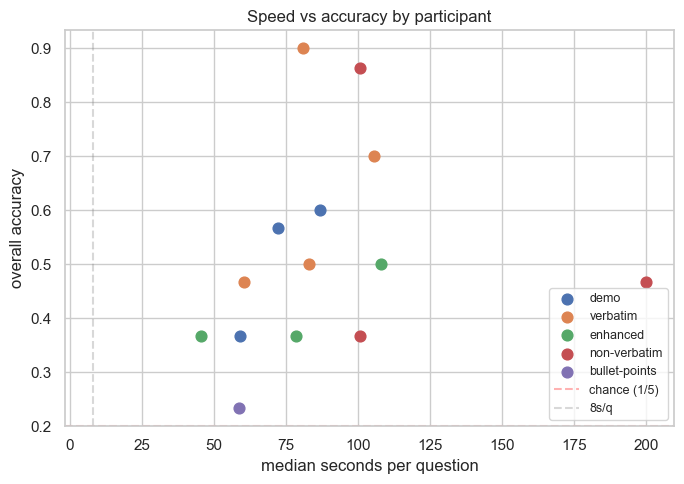

In [19]:
# Speed vs accuracy by participant — handy for spotting outliers.
pp = (scored.groupby(['prolific_id','style'])['correct']
      .agg(['mean','count']).rename(columns={'mean':'accuracy','count':'n_items'})
      .reset_index())
pp = pp.merge(pp_timing[['prolific_id','median_q_sec']], on='prolific_id', how='left')
display(pp.sort_values('median_q_sec'))

fig, ax = plt.subplots(figsize=(7,5))
for s in pp['style'].dropna().unique():
    sub = pp[pp['style']==s]
    ax.scatter(sub['median_q_sec'], sub['accuracy'], label=s, s=60)
ax.axhline(0.2, color='red', alpha=0.3, linestyle='--', label='chance (1/5)')
ax.axvline(8,   color='gray', alpha=0.3, linestyle='--', label='8s/q')
ax.set_xlabel('median seconds per question'); ax.set_ylabel('overall accuracy')
ax.set_title('Speed vs accuracy by participant')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

## 7. Demographics

Two sources of demographic info per participant:

- **Prolific export** — `data/pilot1-prolific_demographic_export_*.csv` — age, sex, ethnicity, country, language, student/employment status, time taken on Prolific's clock.
- **Study-collected** — `event_type == 'demographic'` rows in the logging CSV — education, gender, race, occupation, transcripts-in-work, voice-tech freq/accuracy, parole-experience, U.S. state.

We also do a quick sanity check (Prolific Sex vs our internal Gender).

In [20]:
import glob

prolific_paths = sorted(Path('../data').glob('pilot1-prolific_demographic_export_*.csv'))
print('Prolific CSV(s):', [p.name for p in prolific_paths])
prolific = pd.concat([pd.read_csv(p) for p in prolific_paths], ignore_index=True)
prolific = prolific.rename(columns={'Participant id': 'prolific_id'})
print(f'{len(prolific)} Prolific participants')
prolific.head(3)

Prolific CSV(s): ['pilot1-prolific_demographic_export_69fdac3588e5dd8251a7bbe1.csv']
23 Prolific participants


,Submission id,prolific_id,Status,Custom study tncs accepted at,Started at,Completed at,Reviewed at,Archived at,Time taken,Completion code,...,Fluent languages,Age,Sex,Ethnicity simplified,Country of birth,Country of residence,Nationality,Language,Student status,Employment status
0,69fdb057d000e424a458ffbe,69e7e517df40e6470ac35886,APPROVED,Not Applicable,2026-05-08T09:46:08.367000Z,2026-05-08T10:52:47.530000Z,2026-05-08T10:52:48.023000Z,2026-05-08T10:53:47.924062Z,4000.0,CJ1Y2CQG,...,English,60,Female,Black,United Kingdom,United States,United States,English,No,Part-Time
1,69fdb2517177c1020b760b24,69fce82bde339dace5d6a513,APPROVED,Not Applicable,2026-05-08T09:52:22.349000Z,2026-05-08T10:20:13.735000Z,2026-05-08T10:20:14.243000Z,2026-05-08T10:21:14.132599Z,1672.0,CJ1Y2CQG,...,English,36,Male,White,Spain,United States,United States,English,No,Full-Time
2,69fdb2b1ae7264b19dec6f91,5f18005918868d0b9752e772,APPROVED,Not Applicable,2026-05-08T09:53:57.848000Z,2026-05-08T11:00:57.080000Z,2026-05-08T11:00:57.562000Z,2026-05-08T11:01:57.439065Z,4020.0,CJ1Y2CQG,...,English,25,Male,White,United States,United States,United States,English,No,Full-Time


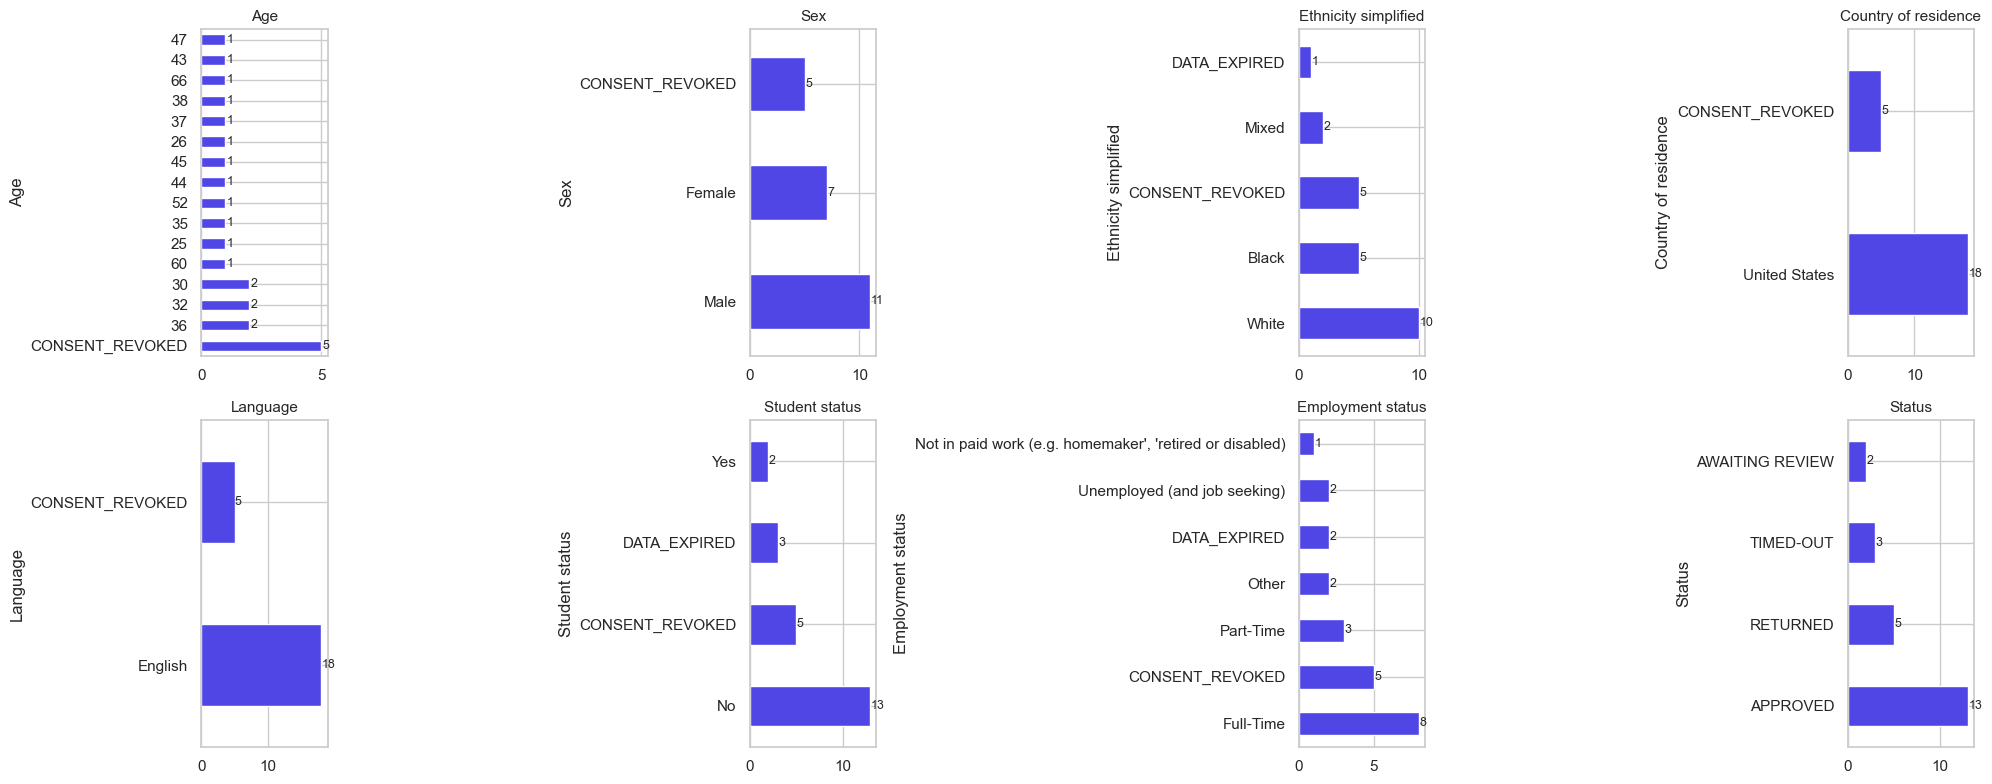

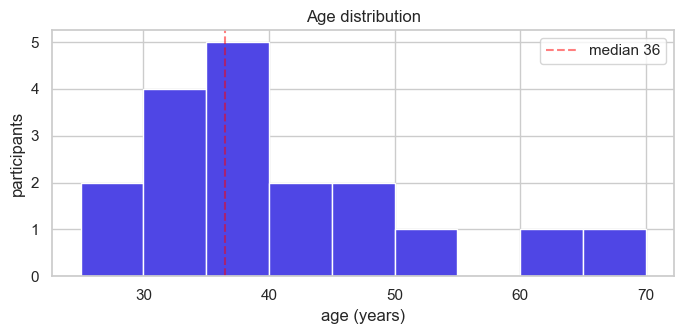

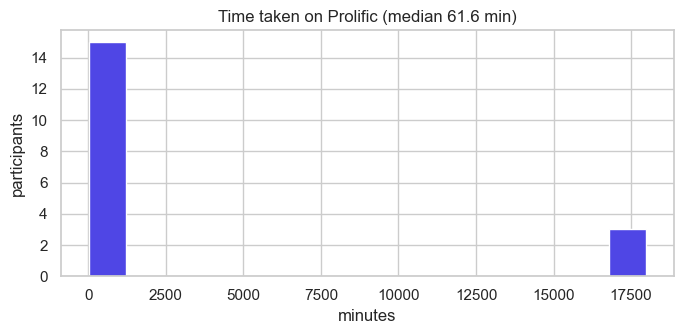

In [21]:
# Prolific-supplied demographics — distributions
prolific_fields = ['Age','Sex','Ethnicity simplified','Country of residence',
                   'Language','Student status','Employment status','Status']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, prolific_fields):
    counts = prolific[col].astype(str).value_counts()
    counts.plot.barh(ax=ax, color='#4F46E5')
    for i, v in enumerate(counts.values):
        ax.text(v + 0.05, i, str(v), va='center', fontsize=9)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
plt.tight_layout(); plt.show()

# Age distribution as a histogram (more useful than barh for continuous-ish)
fig, ax = plt.subplots(figsize=(7,3.5))
ages = pd.to_numeric(prolific['Age'], errors='coerce').dropna()
ax.hist(ages, bins=range(int(ages.min()//5)*5, int(ages.max())+5, 5), color='#4F46E5', edgecolor='white')
ax.set_xlabel('age (years)'); ax.set_ylabel('participants'); ax.set_title('Age distribution')
ax.axvline(ages.median(), color='red', linestyle='--', alpha=0.5, label=f'median {ages.median():.0f}')
ax.legend()
plt.tight_layout(); plt.show()

# Time-taken on Prolific's clock (s → min)
fig, ax = plt.subplots(figsize=(7,3.5))
minutes = pd.to_numeric(prolific['Time taken'], errors='coerce').dropna() / 60
ax.hist(minutes, bins=15, color='#4F46E5', edgecolor='white')
ax.set_xlabel('minutes'); ax.set_ylabel('participants')
ax.set_title(f'Time taken on Prolific (median {minutes.median():.1f} min)')
plt.tight_layout(); plt.show()

97 demographic event rows from 14 participants


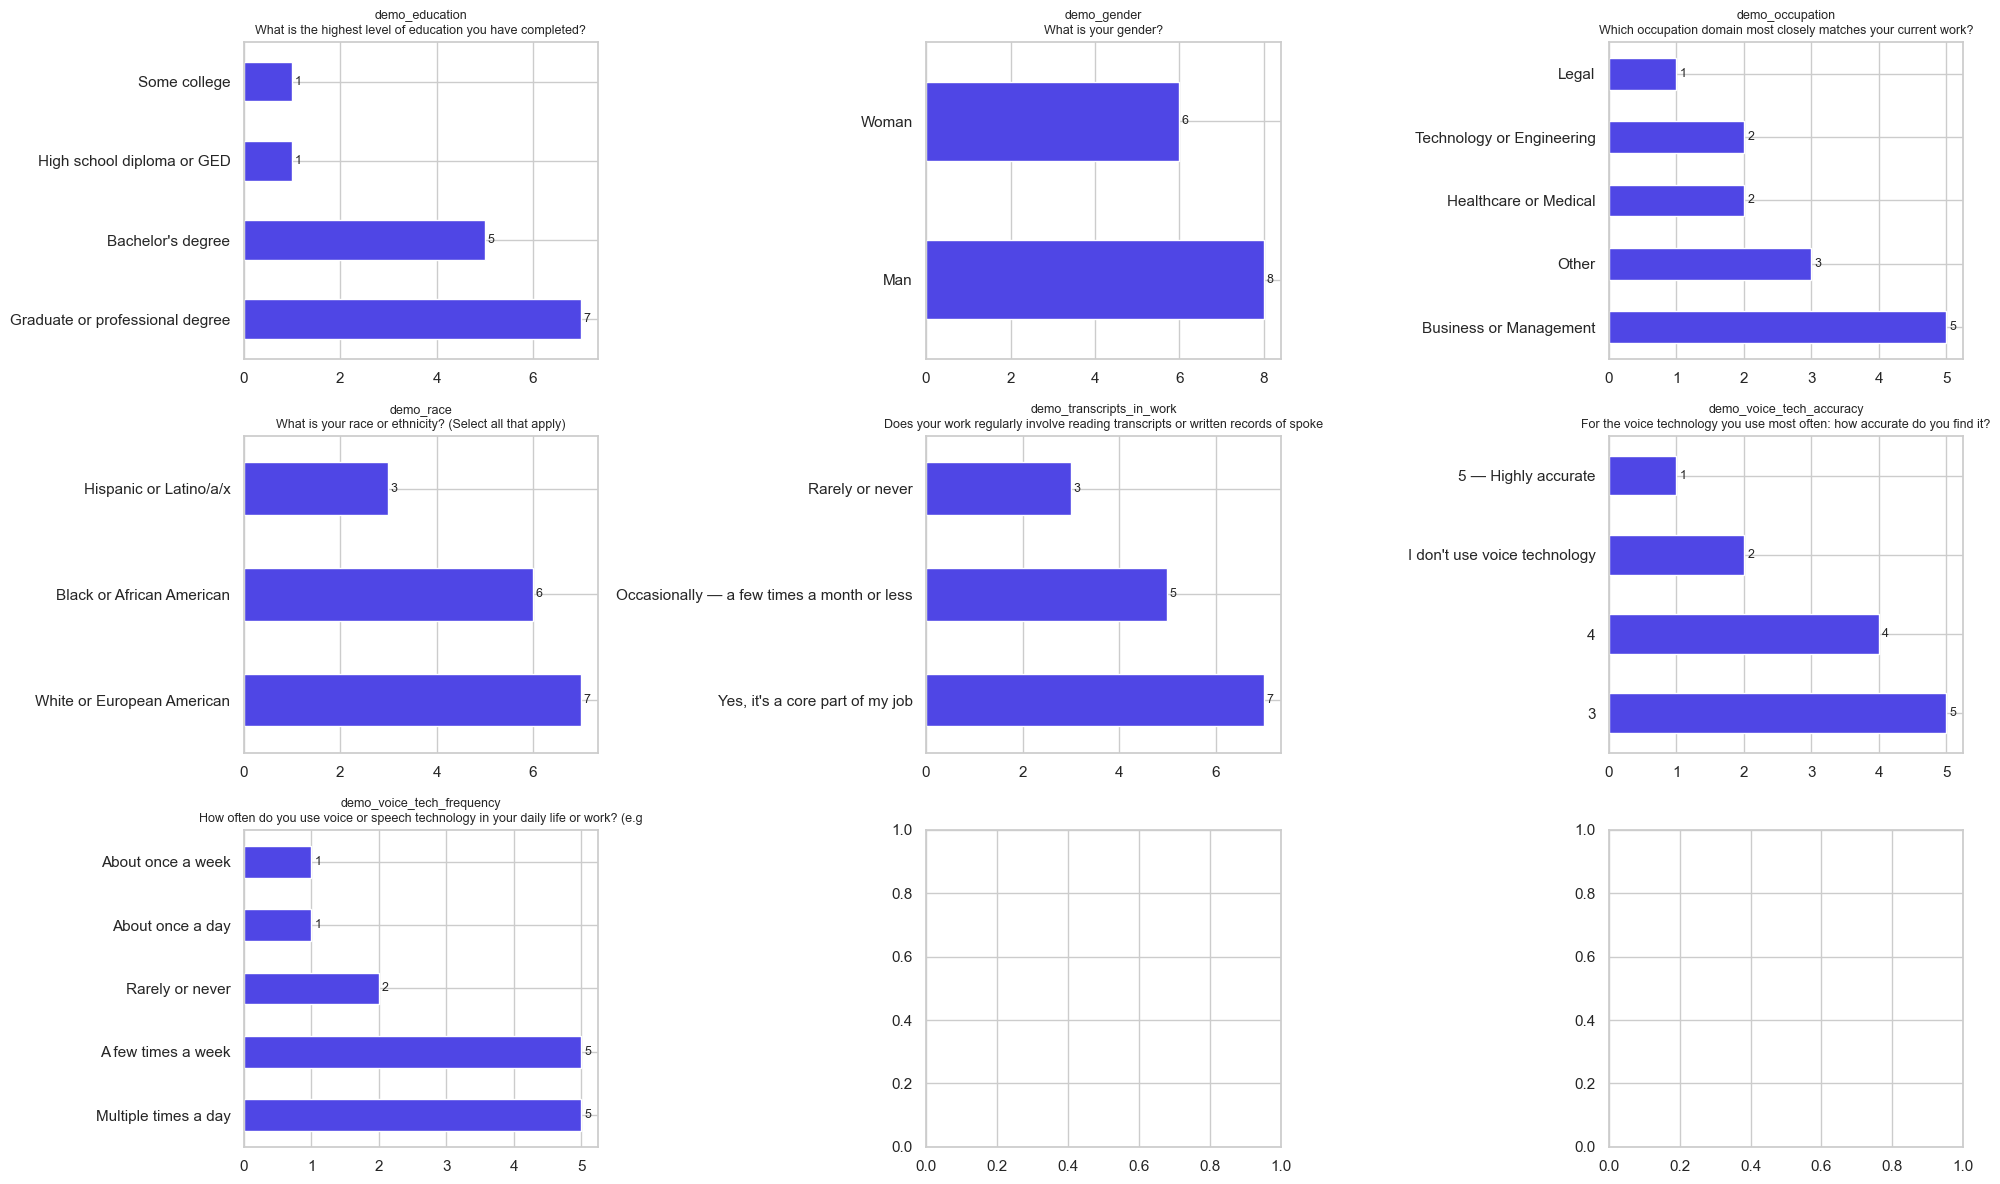

In [22]:
# Study-collected demographics (from `demographic` event rows)
demo = df[df['event_type']=='demographic'].copy()
print(f'{len(demo)} demographic event rows from {demo["prolific_id"].nunique()} participants')

qids = sorted(demo['question_id'].unique())
n = len(qids)
rows_per = 3
nrows = (n + rows_per - 1) // rows_per
fig, axes = plt.subplots(nrows, rows_per, figsize=(20, 4*nrows))
axes = axes.flat if hasattr(axes, 'flat') else [axes]
for ax, qid in zip(axes, qids):
    sub = demo[demo['question_id']==qid]
    # multi-select responses are joined with ' | '; split them
    vals = []
    for r in sub['response'].fillna(''):
        for v in str(r).split(' | '):
            v = v.strip()
            if v: vals.append(v)
    counts = pd.Series(vals).value_counts()
    counts.plot.barh(ax=ax, color='#4F46E5')
    for i, v in enumerate(counts.values):
        ax.text(v + 0.05, i, str(v), va='center', fontsize=9)
    # Question title — strip the leading prefix so it fits
    qtext = sub['question_text'].iloc[0] if len(sub) else qid
    ax.set_title(f'{qid}\n{qtext[:80]}', fontsize=9)
    ax.set_xlabel('')
for ax in list(axes)[n:]: ax.axis('off')
plt.tight_layout(); plt.show()

In [23]:
# Sanity check — Prolific Sex vs our internal Gender (cross-tab on shared PIDs)
gender_rows = demo[demo['question_id']=='demo_gender'][['prolific_id','response']].rename(columns={'response':'self_reported_gender'})
joined = prolific[['prolific_id','Sex']].merge(gender_rows, on='prolific_id', how='inner')
print(f'{len(joined)} participants in both Prolific export and our gender event')
ct = pd.crosstab(joined['Sex'], joined['self_reported_gender'], margins=True, margins_name='Total')
display(ct)

# Also flag PIDs in Prolific export that have NO demographic events (didn't reach Page 2)
missing_demo = set(prolific['prolific_id']) - set(demo['prolific_id'])
print(f'\nPIDs in Prolific export but missing demographic events: {len(missing_demo)}')
if missing_demo:
    print('  e.g.', list(missing_demo)[:5])

# And the reverse — PIDs with demographic events but no Prolific row (probably TEST)
missing_prolific = set(demo['prolific_id']) - set(prolific['prolific_id']) - {''}
print(f'PIDs with demographic events but missing from Prolific export: {len(missing_prolific)}')
if missing_prolific:
    print('  e.g.', list(missing_prolific)[:5])

14 participants in both Prolific export and our gender event


self_reported_gender,Man,Woman,Total
Sex,,,
Female,0,6,6
Male,8,0,8
Total,8,6,14



PIDs in Prolific export but missing demographic events: 9
  e.g. ['69fce82bde339dace5d6a513', '698ce4ba931f89581ecc6d7d', '69f18f5a030aa2d28f548f91', '69eccab0461ada267447d68d', '612274842d4805447451f87b']
PIDs with demographic events but missing from Prolific export: 0
